# Adaptive Learning Rates (AdaGrad & RMSprop)

## The idea
Instead of one fixed learning rate for all weights, give **each weight its own step size**,
adjusted automatically from its gradient history.

The rule (roughly):

$$\text{step for } w_i = \frac{\eta}{\sqrt{\text{accumulated squared gradients of } w_i}} \times \text{gradient}$$

- The **gradient** stays in the numerator (direction & size of the move).
- The **squared, accumulated gradients** go in the **denominator** (under a square root).
- Weight with **big/steep** gradients → big denominator → **smaller** step (stops overshooting).
- Weight with **small/gentle** gradients → small denominator → **larger** step (stops crawling).

This solves the "one learning rate can't fit all directions" problem (from the zigzag demo)
by not using one rate.

## Two versions
- **AdaGrad** — accumulates *all* past squared gradients. Denominator grows forever →
  step size shrinks toward zero → **learning stalls**.
- **RMSprop** — uses a *decaying* average (recent gradients weighted more, old ones fade).
  Denominator stays bounded → steps don't die. **This is the practical version** and the
  ancestor of Adam.

Final loss:
  plain GD : 3.594e+58  <- DIVERGED at this eta
  AdaGrad  : 58.47  <- survived but stalled
  RMSprop  : 8.216  <- survived and progressed

Effective step size for w1 (gentle direction):
  AdaGrad  start: 0.0056 end: 0.000793 (shrinking to 0)
  RMSprop  start: 0.0176 end: 0.013317 (stays healthy)


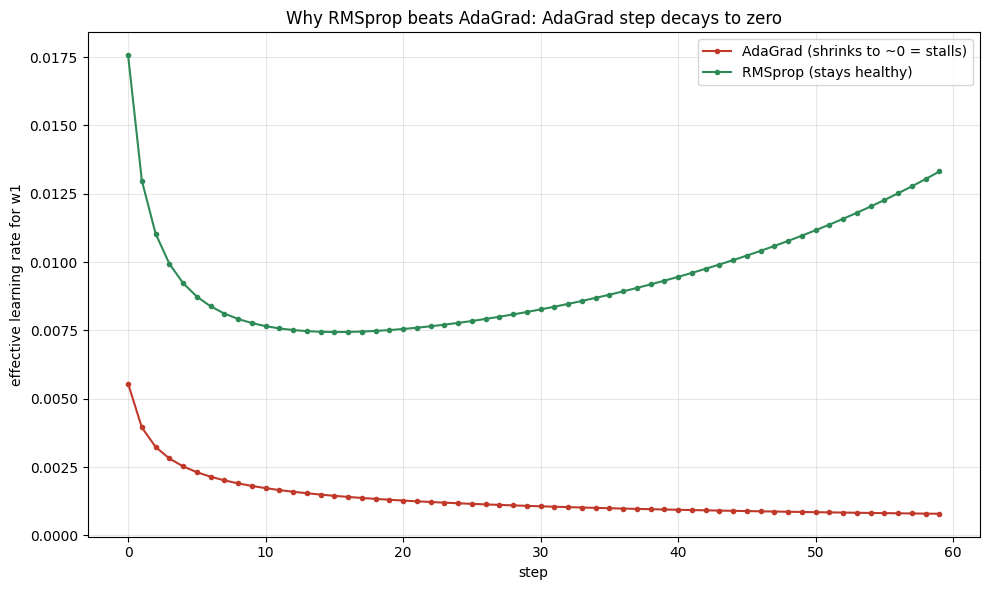

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Narrow valley: steep in w2, gentle in w1
def loss(w): return w[0]**2 + 20*w[1]**2
def grad(w): return np.array([2*w[0], 40*w[1]])


# Weigths
start = np.array([9.0, 1.0]);
steps = 60;
# Learning rate
eta = 0.1


def plain():
    w = start.copy(); path=[w.copy()]
    for _ in range(steps):
        w = w - eta*grad(w); path.append(w.copy())
    return np.array(path)

def adagrad():
    w = start.copy(); path=[w.copy()]; G = np.zeros(2); eps=1e-8; ss=[]
    for _ in range(steps):
        g = grad(w)
        G += g**2                       # accumulate ALL history (never decays)
        adj = eta/(np.sqrt(G)+eps)
        w = w - adj*g; path.append(w.copy()); ss.append(adj.copy())
    return np.array(path), np.array(ss)

def rmsprop(beta=0.9):
    w = start.copy(); path=[w.copy()]; G = np.zeros(2); eps=1e-8; ss=[]
    for _ in range(steps):
        g = grad(w)
        G = beta*G + (1-beta)*g**2      # DECAYING average (recent weighted more)
        adj = eta/(np.sqrt(G)+eps)
        w = w - adj*g; path.append(w.copy()); ss.append(adj.copy())
    return np.array(path), np.array(ss)

p_plain = plain()
p_ada, ss_ada = adagrad()
p_rms, ss_rms = rmsprop()


print("Final loss:")
print("  plain GD :", f"{loss(p_plain[-1]):.3e}", " <- DIVERGED at this eta")
print("  AdaGrad  :", round(loss(p_ada[-1]),3), " <- survived but stalled")
print("  RMSprop  :", round(loss(p_rms[-1]),3), " <- survived and progressed")
print()
print("Effective step size for w1 (gentle direction):")
print("  AdaGrad  start:", round(ss_ada[0,0],4), "end:", round(ss_ada[-1,0],6), "(shrinking to 0)")
print("  RMSprop  start:", round(ss_rms[0,0],4), "end:", round(ss_rms[-1,0],6), "(stays healthy)")


plt.figure(figsize=(10,6))
plt.plot(ss_ada[:,0], 'o-', color='#c0392b', markersize=3, label='AdaGrad (shrinks to ~0 = stalls)')
plt.plot(ss_rms[:,0], 'o-', color='#2e8b57', markersize=3, label='RMSprop (stays healthy)')
plt.xlabel('step'); plt.ylabel('effective learning rate for w1')
plt.title('Why RMSprop beats AdaGrad: AdaGrad step decays to zero')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()